# Grounding Lines

- Groundlines
    * Description: This data set, part of the NASA Making Earth System Data Records for Use in Research Environments (MEaSUREs) program, provides 22 years of comprehensive high-resolution mapping of grounding lines in Antarctica from 1992 to 2014. The data were derived using differential satellite synthetic aperture radar interferometry (DInSAR) measurements from the following platforms: Earth Remote Sensing Satellites 1 and 2 (ERS-1 and ERS-2), RADARSAT-1, RADARSAT-2, the Advanced Land Observing System Phased Array type L-band Synthetic Aperture Radar (ALOS PALSAR), Cosmo Skymed, and Copernicus Sentinel-1.
    * Original Data Source: https://cmr.earthdata.nasa.gov/virtual-directory/collections/C3291177478-NSIDC_CPRD
    * Reference: https://nsidc.org/sites/default/files/nsidc-0498-v002-userguide_1.pdf
    * OSC entry: https://opensciencedata.esa.int/products/grounding-line-position-antarctica/collection
    * License: CC0-1.0
    * Repo Folder: ./datasets/groundlines

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/groundlines/InSAR_GL_Antarctica.parquet'

In [6]:
gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
)
gdf['SENSOR'].unique()

array(['PALSAR', 'ERS', 'R2', 'RSAT', 'SENTINEL1A', 'CSK'], dtype=object)

Text(0.5, 1.0, 'Groundline Sensors')

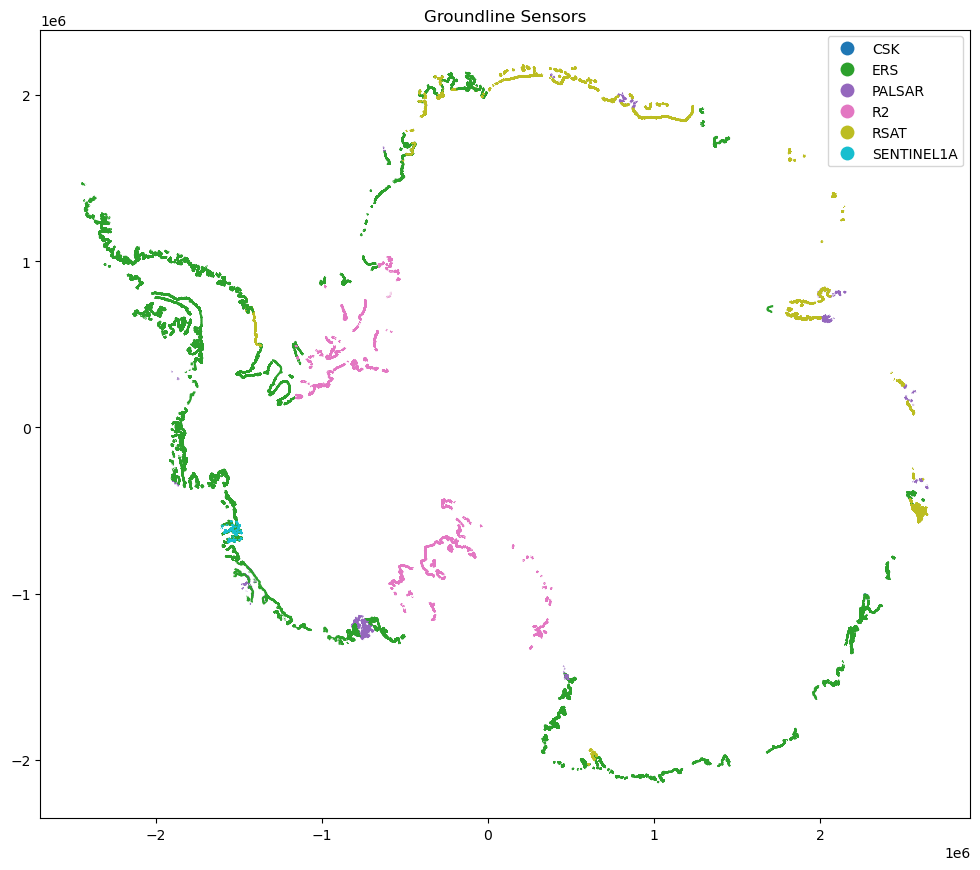

In [7]:
fig, ax = plt.subplots(figsize=(12,12))
gdf.to_crs('epsg:3031').plot(column='SENSOR', legend=True, ax=ax)
ax.set_title('Groundline Sensors')

Text(0.5, 1.0, 'Groundline Year')

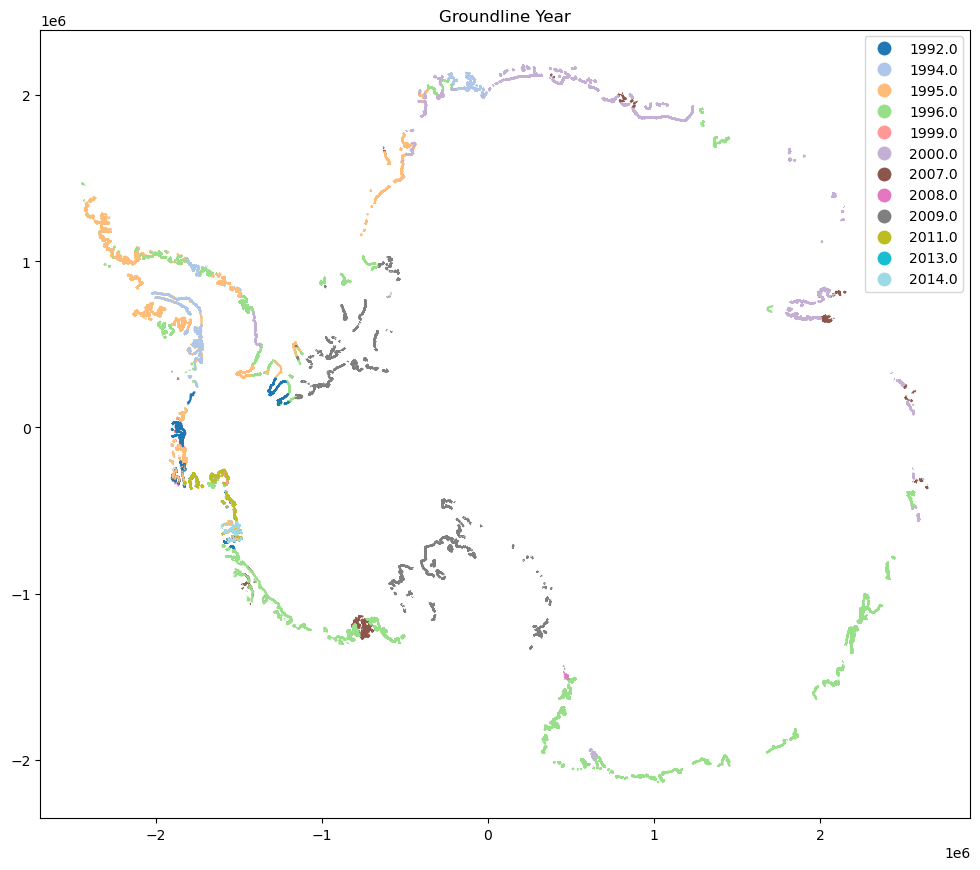

In [8]:
fig, ax = plt.subplots(figsize=(12,12))
gdf.to_crs('epsg:3031').plot(column=gdf['DATE1'].dt.year.round(), 
                             legend=True, categorical=True, ax=ax, cmap='tab20')
ax.set_title('Groundline Year')